# COGS 108 - EDA Checkpoint

## Authors

- Fawaz Alsenayin: Data curation, Software (GitHub setup, dataset merging, OLS model)
- Ghasaq Al Khalaf: Background research, Writing – original draft (research question)
- Hadia Beshir: Conceptualization, Analysis, Visualization
- Shelby Giang:  Analysis, Visualization, Writing – review & editing (hypothesis)
- Nawar Kidwai: Background research, Data curation, Software (dataset merging)

# Research Question

Is higher dietary linoleic acid intake, used as a proxy for seed-oil-rich diets, associated with higher BMI and total cholesterol levels among U.S. adults?

## Background and Prior Work

Dietary patterns in the United States have shifted toward greater consumption of ultra-processed foods, many of which are energy-dense and contain refined vegetable oils. Linoleic acid is an omega-6 polyunsaturated fatty acid commonly found in oils such as corn, sunflower, soybean, and canola oil.[^1] According to the CDC’s National Center for Health Statistics, ultra-processed foods made up about 55% of total daily calorie intake among people age 1 and older in the United States from August 2021 to August 2023, with an even higher percentage among youth.[^1] Prior research has also found that higher consumption of ultra-processed foods is associated with increased risk of obesity, type 2 diabetes, and cardiovascular disease.[^2] However, research on linoleic acid itself is more mixed, with some evidence suggesting that replacing saturated fats with linoleic-acid-rich unsaturated fats may improve cardiovascular outcomes.[^3] Because of this, our project focuses on whether higher dietary linoleic acid intake is associated with obesity and cardiovascular risk markers, rather than assuming it is directly harmful.

This topic is important because many Americans may not know how much linoleic acid they consume through fast-food and ultra-processed diets. Over the 20th century, the U.S. diet shifted away from traditional animal fats such as butter and lard toward greater use of industrial vegetable oils, which increased dietary exposure to omega-6 fatty acids.[^4] Omega-6 fatty acids are essential in the diet, but some researchers argue that a high omega-6 to omega-3 ratio may contribute to inflammation-related health concerns.[^4] Omega-3 fatty acids, which are found in foods such as salmon, sardines, tuna, chia seeds, and flaxseeds, may help balance inflammatory processes in the body.[^4] This background helps explain why linoleic acid intake is debated and why it is useful to study its relationship with measurable health outcomes.

For our project, we will focus on obesity and cardiovascular risk because these outcomes can be measured using NHANES variables. BMI will be used as a marker of obesity risk, with BMI of 30 or higher commonly used to classify obesity. Total cholesterol will be used as a cardiovascular risk marker because high cholesterol is associated with greater risk of heart disease. However, these measures have limitations: BMI does not fully capture body composition, and total cholesterol alone does not fully diagnose cardiovascular disease. Therefore, our analysis will examine whether higher linoleic acid intake is associated with BMI and total cholesterol, while clearly stating that the results do not prove causation.

References:
[^1]: Williams, A. M., Couch, C. A., Emmerich, S. E., & Ogburn, D. F. (2025). *Ultra-processed food consumption among youth and adults: United States, August 2021–August 2023*. NCHS Data Brief, No. 536. Centers for Disease Control and Prevention. https://www.cdc.gov/nchs/products/databriefs/db536.htm

[^2]: Pagliai, G., Dinu, M., Madarena, M. P., Bonaccio, M., Iacoviello, L., & Sofi, F. (2021). *Consumption of ultra-processed foods and health status: A systematic review and meta-analysis*. *British Journal of Nutrition, 125*(3), 308–318. https://www.cambridge.org/core/journals/british-journal-of-nutrition/article/consumption-of-ultraprocessed-foods-and-health-status-a-systematic-review-and-metaanalysis/

[^3]: Johns Hopkins Bloomberg School of Public Health. (2025). *The evidence behind seed oils’ health effects*. https://publichealth.jhu.edu/2025/the-evidence-behind-seed-oils-health-effects

[^4]: Simopoulos, A. P. (2002). The importance of the ratio of omega-6/omega-3 essential fatty acids. *Biomedicine & Pharmacotherapy, 56*(8), 365–379. https://doi.org/10.1016/S0753-3322(02)00253-6

# Hypothesis


We hypothesize that higher dietary linoleic acid intake, commonly found in fast-food and ultra-processed diets that use seed oils, will be associated with higher obesity and cardiovascular risk among U.S. adults. More specifically, we predict that adults with higher linoleic acid intake will have higher average BMI, higher obesity prevalence, and higher total cholesterol levels compared to adults with lower linoleic acid intake. This prediction is based on prior research showing that ultra-processed food consumption is associated with obesity and cardiovascular disease risk, while our project uses linoleic acid intake as a measurable proxy for seed-oil-rich dietary patterns.

## Data

### Data Overview

We are using four NHANES August 2021–August 2023 datasets from the CDC/National Center for Health Statistics. These datasets are publicly available as XPT files and do not require special permission. We will combine them using `SEQN`, the respondent sequence number, so that each row in our final dataset represents one adult participant.

**Dataset #1**
- **Dataset Name:** Dietary Interview - Total Nutrient Intakes, First Day (`DR1TOT_L`)
- **Link to the dataset:** https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DR1TOT_L.htm
- **Number of observations:** 8,860
- **Number of variables:** 168
- **Relevant variables:** `SEQN` for participant ID, `DR1TP182` for linoleic acid intake in grams, `DR1TKCAL` for total calories in kcal, and `DR1TTFAT` for total fat in grams.
- **Shortcomings:** This dataset uses a 24-hour dietary recall, so one day may not represent a participant’s usual diet. It also does not directly identify seed oil or fast-food intake, so we use linoleic acid intake as a proxy.

**Dataset #2**
- **Dataset Name:** Body Measures (`BMX_L`)
- **Link to the dataset:** https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BMX_L.htm
- **Number of observations:** 8,860
- **Number of variables:** 22
- **Relevant variables:** `SEQN` for participant ID and `BMXBMI` for Body Mass Index in kg/m².
- **Shortcomings:** BMI is useful for measuring obesity risk, but it does not fully describe body composition or overall health.

**Dataset #3**
- **Dataset Name:** Cholesterol - Total (`TCHOL_L`)
- **Link to the dataset:** https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/TCHOL_L.htm
- **Number of observations:** 8,068
- **Number of variables:** 4
- **Relevant variables:** `SEQN` for participant ID and `LBXTC` for total cholesterol in mg/dL.
- **Shortcomings:** Total cholesterol is only one cardiovascular risk marker. It does not fully measure cardiovascular disease risk by itself.

**Dataset #4**
- **Dataset Name:** Demographic Variables and Sample Weights (`DEMO_L`)
- **Link to the dataset:** https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.htm
- **Number of observations:** 11,933
- **Number of variables:** 27
- **Relevant variables:** `SEQN` for participant ID, `RIDAGEYR` for age, `RIAGENDR` for sex, `RIDRETH3` for race/ethnicity, and `INDFMPIR` for income-to-poverty ratio.
- **Shortcomings:** Some demographic variables are limited for privacy reasons, and this dataset does not include every possible lifestyle factor that may affect BMI or cholesterol.

We plan to merge these datasets using `SEQN`. After merging, we will filter to adults, remove missing values in the main analysis variables, and create new variables for obesity status and high cholesterol status.

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

### Dataset 1 - Merged NHANES Analysis Dataset

For this EDA checkpoint, we use the cleaned NHANES datasets from the previous data checkpoint and merge them into one analysis dataset. The cleaned files include Day 1 dietary nutrient intake, body measures, total cholesterol, and demographics. Each dataset was already cleaned separately, so this step focuses on combining them using `SEQN`, the participant ID.

The merged dataset includes linoleic acid intake in grams, total calories, total fat, BMI, obesity status, total cholesterol, high cholesterol status, age, sex, race/ethnicity, and income-to-poverty ratio. This final dataset is the one we will use for exploratory data analysis. We use an inner merge so that each participant included in the EDA has data available for the main diet, BMI, cholesterol, and demographic variables.

A limitation of this merged dataset is that some participants are removed during the inner merge because they are missing one or more required datasets. This reduces the final sample size, but it keeps the analysis consistent because every row has the variables needed for our research question.

In [2]:
# Dataset 1 - Merged NHANES Analysis Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

processed_path = Path("data/02-processed")

diet_clean = pd.read_csv(processed_path / "diet_clean.csv")
bmx_clean = pd.read_csv(processed_path / "bmx_clean.csv")
chol_clean = pd.read_csv(processed_path / "chol_clean.csv")
demo_clean = pd.read_csv(processed_path / "demo_clean.csv")

# Demonstrate size of each cleaned dataset before merging
print("Cleaned diet dataset shape:", diet_clean.shape)
print("Cleaned body measures dataset shape:", bmx_clean.shape)
print("Cleaned cholesterol dataset shape:", chol_clean.shape)
print("Cleaned demographics dataset shape:", demo_clean.shape)

# Merge datasets using participant ID
df = demo_clean.merge(diet_clean, on="SEQN", how="inner")
df = df.merge(bmx_clean, on="SEQN", how="inner")
df = df.merge(chol_clean, on="SEQN", how="inner")
df.to_csv(processed_path / "merged_eda_dataset.csv", index=False)

# Create linoleic acid intake groups for EDA
df["linoleic_group"] = pd.qcut(
    df["linoleic_acid_g"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Check final merged dataset
print("Final merged EDA dataset shape:", df.shape)
print("Duplicate participant IDs:", df["SEQN"].duplicated().sum())

display(df.head())

Cleaned diet dataset shape: (6694, 4)
Cleaned body measures dataset shape: (8471, 3)
Cleaned cholesterol dataset shape: (6890, 3)
Cleaned demographics dataset shape: (7809, 5)
Final merged EDA dataset shape: (4361, 13)
Duplicate participant IDs: 0


,SEQN,age,sex,race_ethnicity,income_poverty_ratio,linoleic_acid_g,calories_kcal,total_fat_g,bmi,obese,total_cholesterol_mg_dl,high_cholesterol,linoleic_group
0,130378.0,43.0,1.0,6.0,5.00,9.905,1740.0,55.07,27.0,False,264.0,True,Low
1,130379.0,66.0,1.0,3.0,5.00,22.948,2741.0,67.18,33.5,True,214.0,True,High
2,130380.0,44.0,2.0,2.0,1.41,10.397,1995.0,65.38,29.7,False,187.0,False,Low
3,130386.0,34.0,1.0,1.0,1.33,24.922,2422.0,116.54,30.2,True,183.0,False,High
4,130387.0,68.0,2.0,3.0,1.32,92.070,3849.0,234.39,42.6,True,203.0,True,High


## Results

### Exploratory Data Analysis

In this section, we explore the merged NHANES analysis dataset to look for early patterns related to our research question. Our main predictor is linoleic acid intake in grams, which we use as a proxy for seed-oil-rich diets commonly found in fast-food and ultra-processed foods. Our main health-risk markers are BMI, obesity status, total cholesterol, and high cholesterol status.

The EDA first summarizes the main variables, then examines the distribution of linoleic acid intake. After that, we compare BMI, obesity prevalence, total cholesterol, and high cholesterol prevalence across low, medium, and high linoleic acid intake groups. These results will help us see whether the data shows patterns that support our hypothesis before moving into formal analysis.

### Section 1 - Summary of Key Variables

Before comparing groups, we summarize the main variables in the merged dataset. This helps us understand the range and average values of linoleic acid intake, calories, total fat, BMI, cholesterol, and age. We also check the proportion of participants classified as obese or having high cholesterol.

In [3]:
key_vars = [
    "linoleic_acid_g",
    "calories_kcal",
    "total_fat_g",
    "bmi",
    "total_cholesterol_mg_dl",
    "age"
]

display(df[key_vars].describe())

display(df[["obese", "high_cholesterol"]].mean())

,linoleic_acid_g,calories_kcal,total_fat_g,bmi,total_cholesterol_mg_dl,age
count,4.361000e+03,4.361000e+03,4.361000e+03,4361.000000,4361.000000,4361.000000
mean,1.707380e+01,1.981241e+03,8.372148e+01,29.936849,188.822059,55.097455
std,1.183566e+01,9.041287e+02,4.633036e+01,7.253454,42.507500,16.707505
min,5.397605e-79,5.397605e-79,5.397605e-79,14.100000,62.000000,20.000000
25%,9.250000e+00,1.386000e+03,5.231000e+01,24.900000,159.000000,41.000000
50%,1.470500e+01,1.850000e+03,7.643000e+01,28.600000,186.000000,59.000000
75%,2.184100e+01,2.445000e+03,1.057900e+02,33.700000,215.000000,68.000000
max,1.714240e+02,1.044600e+04,5.056200e+02,74.800000,438.000000,80.000000


obese               0.420316
high_cholesterol    0.370557
dtype: float64

### Section 1 - Interpretation

The merged EDA dataset contains 4,361 adult participants. On average, participants consumed about 17.07 grams of linoleic acid, 1,981 calories, and 83.72 grams of total fat in the Day 1 dietary recall. The average BMI was 29.94, which is close to the obesity cutoff of 30, and about 42.03% of participants were classified as obese. The average total cholesterol level was 188.82 mg/dL, and about 37.06% of participants had high cholesterol. These summary statistics show that obesity and high cholesterol are common in this sample, which makes BMI and cholesterol useful health-risk markers for our analysis.

### Section 2 - Distribution of Linoleic Acid Intake

Next, we examine the distribution of linoleic acid intake. Linoleic acid intake is our main predictor variable because we are using it as a measurable proxy for seed-oil-rich diets commonly found in fast-food and ultra-processed foods.

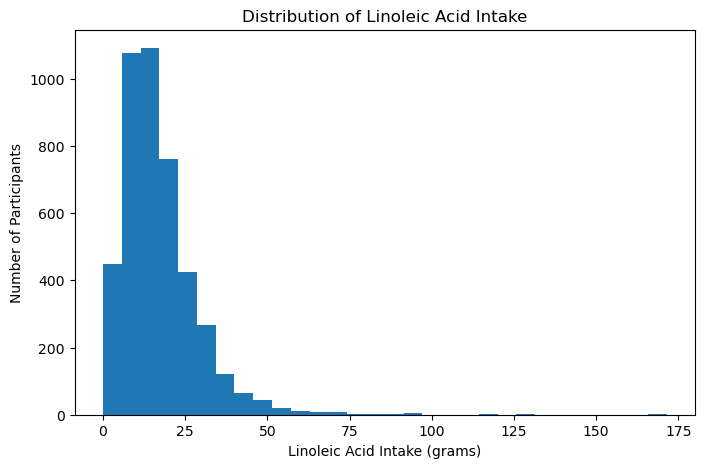

linoleic_group
Low       1454
Medium    1454
High      1453
Name: count, dtype: int64

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(df["linoleic_acid_g"], bins=30)
plt.xlabel("Linoleic Acid Intake (grams)")
plt.ylabel("Number of Participants")
plt.title("Distribution of Linoleic Acid Intake")
plt.show()

display(df["linoleic_group"].value_counts().sort_index())

### Section 2 - Interpretation

The histogram shows that linoleic acid intake is right-skewed, meaning most participants consumed lower to moderate amounts, while a smaller number consumed very high amounts. Most participants appear to fall between about 5 and 30 grams of linoleic acid intake, with a few extreme values above 75 grams. The `linoleic_group` variable divides the dataset into three almost equal groups: 1,454 participants in the low group, 1,454 in the medium group, and 1,453 in the high group. This grouping is useful because it allows us to compare BMI, obesity prevalence, cholesterol, and high cholesterol prevalence across different levels of linoleic acid intake.

### Section 3 - BMI and Obesity by Linoleic Acid Intake Group

This section compares BMI and obesity prevalence across low, medium, and high linoleic acid intake groups. This helps us explore whether participants with higher linoleic acid intake also show higher obesity risk.

,bmi,obese
linoleic_group,,
Low,30.189752,0.439477
Medium,29.537208,0.403714
High,30.083689,0.417756


<Figure size 800x500 with 0 Axes>

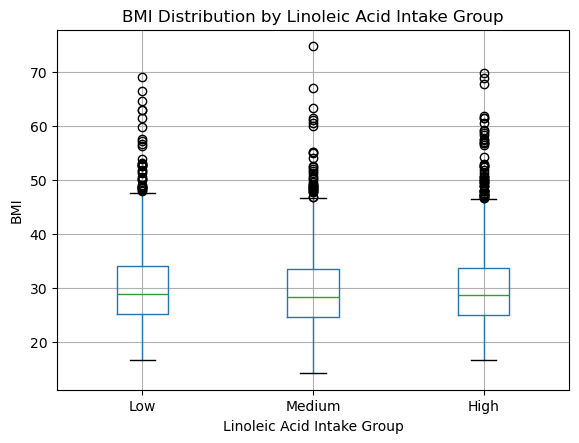

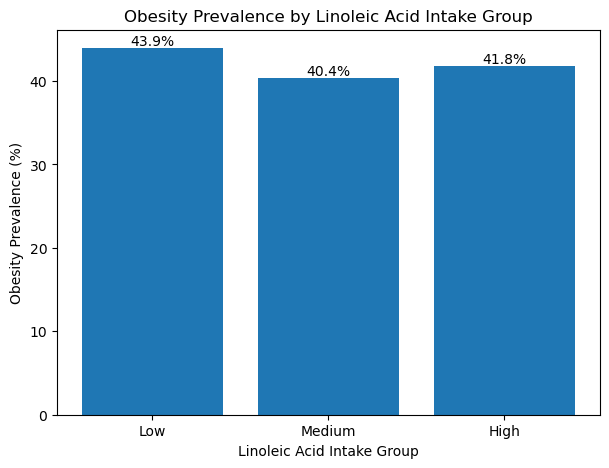

In [5]:
bmi_by_group = df.groupby("linoleic_group", observed=False)[["bmi", "obese"]].mean()
display(bmi_by_group)

plt.figure(figsize=(8, 5))
df.boxplot(column="bmi", by="linoleic_group")
plt.xlabel("Linoleic Acid Intake Group")
plt.ylabel("BMI")
plt.title("BMI Distribution by Linoleic Acid Intake Group")
plt.suptitle("")
plt.show()

obesity_percent = bmi_by_group["obese"] * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(obesity_percent.index, obesity_percent)
plt.xlabel("Linoleic Acid Intake Group")
plt.ylabel("Obesity Prevalence (%)")
plt.title("Obesity Prevalence by Linoleic Acid Intake Group")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

### Section 3 - Interpretation

The BMI and obesity results do not show a clear increasing pattern across linoleic acid intake groups. The low group had an average BMI of about 30.19, the medium group had an average BMI of about 29.54, and the high group had an average BMI of about 30.08. Obesity prevalence was also similar across groups, with about 43.95% in the low group, 40.37% in the medium group, and 41.78% in the high group. Based on this exploratory comparison, higher linoleic acid intake does not appear to be clearly associated with higher BMI or obesity prevalence. However, this is only a descriptive comparison and does not control for possible confounding variables such as age, sex, total calories, total fat intake, or income.

### Section 4 - Total Cholesterol by Linoleic Acid Intake Group

This section compares total cholesterol and high cholesterol prevalence across linoleic acid intake groups. Total cholesterol is used as our cardiovascular risk marker.

,total_cholesterol_mg_dl,high_cholesterol
linoleic_group,,
Low,189.544704,0.380330
Medium,188.895461,0.375516
High,188.025465,0.355816


<Figure size 800x500 with 0 Axes>

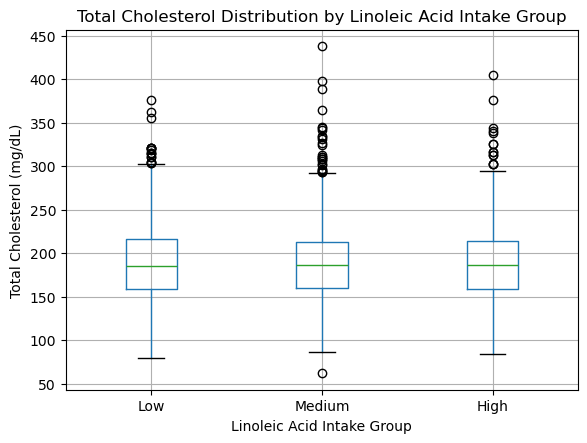

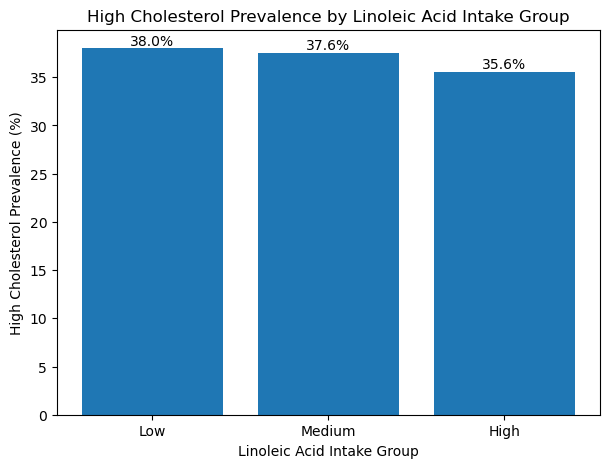

In [6]:
chol_by_group = df.groupby("linoleic_group", observed=False)[[
    "total_cholesterol_mg_dl",
    "high_cholesterol"
]].mean()

display(chol_by_group)

plt.figure(figsize=(8, 5))
df.boxplot(column="total_cholesterol_mg_dl", by="linoleic_group")
plt.xlabel("Linoleic Acid Intake Group")
plt.ylabel("Total Cholesterol (mg/dL)")
plt.title("Total Cholesterol Distribution by Linoleic Acid Intake Group")
plt.suptitle("")
plt.show()

high_cholesterol_percent = chol_by_group["high_cholesterol"] * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(high_cholesterol_percent.index, high_cholesterol_percent)
plt.xlabel("Linoleic Acid Intake Group")
plt.ylabel("High Cholesterol Prevalence (%)")
plt.title("High Cholesterol Prevalence by Linoleic Acid Intake Group")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

### Section 4 - Interpretation

The total cholesterol results show a slight decrease across linoleic acid intake groups. The low group had an average total cholesterol of about 189.54 mg/dL, the medium group had about 188.90 mg/dL, and the high group had about 188.03 mg/dL. High cholesterol prevalence also decreased from about 38.03% in the low group to 37.55% in the medium group and 35.58% in the high group. Based on this exploratory comparison, higher linoleic acid intake does not appear to be associated with higher total cholesterol or higher high-cholesterol prevalence. However, this is only a descriptive comparison and does not control for factors such as age, sex, calories, total fat intake, income, or medication use.

### Section 5 - Correlations Between Linoleic Acid Intake and Health Markers

Finally, we examine correlations between linoleic acid intake and the main continuous variables. This gives us an initial sense of whether linoleic acid intake is positively or negatively related to BMI and total cholesterol before formal modeling.

,linoleic_acid_g,bmi,total_cholesterol_mg_dl,calories_kcal,total_fat_g,age
linoleic_acid_g,1.000000,0.005586,-0.004276,0.704421,0.820423,-0.072312
bmi,0.005586,1.000000,-0.054742,-0.033986,0.007504,-0.012222
total_cholesterol_mg_dl,-0.004276,-0.054742,1.000000,-0.016235,-0.012107,-0.019899
calories_kcal,0.704421,-0.033986,-0.016235,1.000000,0.876895,-0.091362
total_fat_g,0.820423,0.007504,-0.012107,0.876895,1.000000,-0.053720
age,-0.072312,-0.012222,-0.019899,-0.091362,-0.053720,1.000000


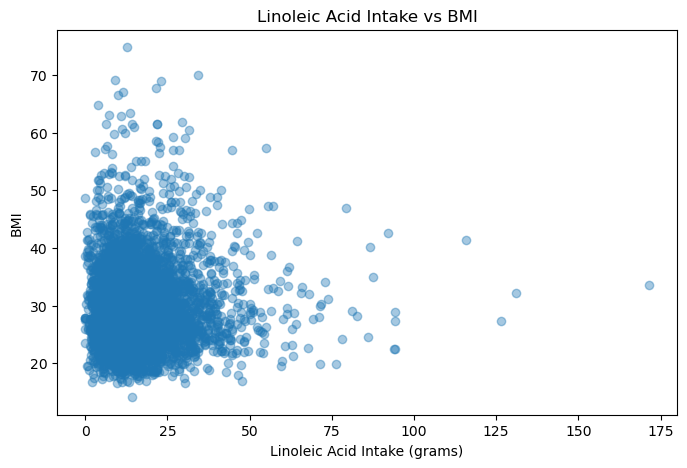

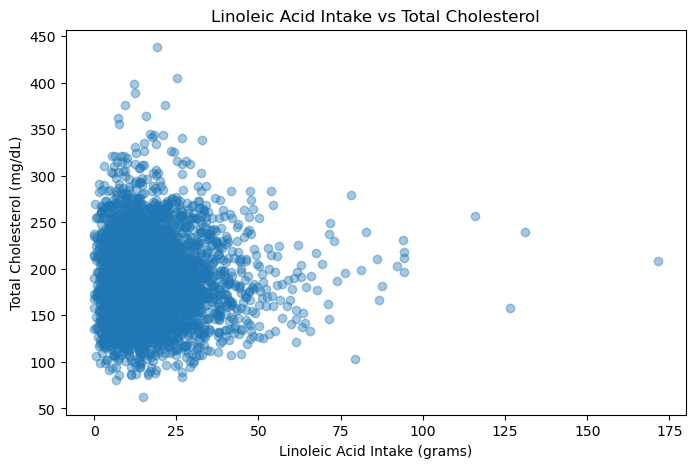

In [7]:
corr_vars = [
    "linoleic_acid_g",
    "bmi",
    "total_cholesterol_mg_dl",
    "calories_kcal",
    "total_fat_g",
    "age"
]

correlations = df[corr_vars].corr()
display(correlations)

plt.figure(figsize=(8, 5))
plt.scatter(df["linoleic_acid_g"], df["bmi"], alpha=0.4)
plt.xlabel("Linoleic Acid Intake (grams)")
plt.ylabel("BMI")
plt.title("Linoleic Acid Intake vs BMI")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["linoleic_acid_g"], df["total_cholesterol_mg_dl"], alpha=0.4)
plt.xlabel("Linoleic Acid Intake (grams)")
plt.ylabel("Total Cholesterol (mg/dL)")
plt.title("Linoleic Acid Intake vs Total Cholesterol")
plt.show()

### Section 5 - Interpretation

The correlation results show that linoleic acid intake has almost no relationship with BMI or total cholesterol in this exploratory analysis. The correlation between linoleic acid intake and BMI is about 0.006, which is extremely close to zero. The correlation between linoleic acid intake and total cholesterol is about -0.004, which is also essentially no relationship. However, linoleic acid intake is strongly correlated with total calories and total fat, with correlations of about 0.70 and 0.82. This makes sense because people who eat more calories and fat overall are also likely to consume more linoleic acid. Based on this EDA, linoleic acid intake alone does not appear to show a strong direct relationship with BMI or cholesterol, but future analysis should control for calories, total fat, age, sex, and income.

## Ethics

Instructions: Keep the contents of this cell. For each item on the checklist
-  put an X there if you've considered the item
-  IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.
  
Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section.  You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.

Here is a [list of real world examples](https://deon.drivendata.org/examples/) for each item in the checklist that can refer to.

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> Example of how to use the checkbox, and also of how you can put in a short paragraph that discusses the way this checklist item affects your project.  Remove this paragraph and the X in the checkbox before you fill this out for your project

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?
 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
 - [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?
 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

### E. Deployment
 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?


## Team Expectations 

Team Expectation 1: Our team is committed to maintaining consistent communication, accountability, and respectful collaboration throughout the duration of the project. We will primarily communicate through Discord and text messaging, and all members agree to check messages at least twice daily to stay updated on deadlines, task assignments, and project progress. We will communicate any scheduling conflicts, delays, ask questions or troubleshoot any issues. We will check-in at 8 P.M. the day before, and on the date of submission, for a particular group assignment. 

Team Expectation 2: To ensure equal participation, responsibilities will be divided based on workload, individual strengths, and availability, while still ensuring that all members contribute to the major components of the project, including research, coding, data analysis, writing, and presentation preparation. Drafts and assigned tasks will be completed by internally agreed-upon deadlines to allow sufficient time for peer review and revisions before final submission. All code and written work will be shared through GitHub to maintain organization, version control, and transparency of contributions.

Team Expectation 3: Our team will conduct daily asynchronous check-ins where members provide updates on completed work, ongoing challenges, and goals for the day. In addition, we will hold regular meetings to review progress, troubleshoot issues, and coordinate upcoming tasks. We agree to provide constructive feedback respectfully and maintain a supportive working environment where all members feel comfortable asking questions or requesting help.

Team Expectation 4: If disagreements arise, we will first attempt to resolve them through open discussion and compromise with all team members. If repeated missed responsibilities or lack of participation arise, the team will privately address the issue with the member first before escalating concerns to course staff if necessary. Our goal is to create an organized and collaborative team dynamic that allows all members to contribute meaningfully.  


## Project Timeline Proposal

| Meeting Date | Meeting Time | Completed Before Meeting | Discuss at Meeting |
|---|---|---|---|
| 5/12 | 8 PM | Data Checkpoint 1 completed | Review and discuss any changes to the Data Checkpoint 1 document |
| 5/13 | 8 PM | Complete full Data Checkpoint 1 by pushing changes into GitHub | Update the team on any possible changes or issues as they arise |
| 5/19 | 8 PM | Explore possible EDA for the appropriate dataset | Plan and discuss possible EDA to be used |
| 5/26 | 8 PM | Complete EDA and start analysis | Review results and connect them to the hypothesis |
| 6/2 | 8 PM | Complete EDA/modeling | Edit the full project and improve visuals |
| 6/9 | 8 PM | Finalize report and prepare video | Record videos and submit final report |